# Calibración de modelos

Objetivo

De acuerdo al analisis realizado en el EDA y los resultados obtenidos en los modelos que se compararon, donde la feature a predecir es clave y es un modelo donde la clasificacion incorrecta es critica (es decir un falso negativo es mas importante que un falso positivo). Al tener clases desbalanceadas es posible que los resultados reales puedan no coincidir con los calculados y cualquier variacion en los resultados es clave para tomar decisiones y determinar si el modelo seleccionado es el correcto. Es por eso que creemos que seria importante analizar la calibracion del o los modelos seleccionados.

Varios de los modelos analizados tuvieron un buen rendimiento incluso similares entre si, Random Forest, Gradient Boosting, SVM.

Es por eso que vamos a medir la calibracion para tener una idea de la incertidumbre del modelo.

Seleccionamos SVM ya que es el modelo que mejores resultados obtuvo en las metricas.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibrationDisplay, calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score, f1_score, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error, fbeta_score, make_scorer, recall_score, precision_score, classification_report, roc_auc_score, confusion_matrix

from sklearn.pipeline import make_pipeline, Pipeline


In [3]:
decision_tree_tuned = joblib.load('../models/decision_tree_tuned.pkl')
random_forest_tuned = joblib.load('../models/random_forest_tuned.pkl')
xgboost_tuned = joblib.load('../models/xgboost_tuned.pkl')
random_forest_classifier_op_tuned = joblib.load('../models/random_forest_classifier_op_tuned.pkl')
svm = joblib.load('../models/svc.pkl')
data = joblib.load('../data/processed_data.pkl')
columns = data['feature_names']
X_train = pd.DataFrame(data['X_train'], columns=columns)
X_test = pd.DataFrame(data['X_test'], columns=columns)
y_train = data['y_train']
y_test = data['y_test']

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Analisis modelo SVM

Para empezar verificamos como se comporta el modelo SVM vs sus versiones calibradas con los metodos isotonic y pratt

In [45]:
y_pred = svm.predict(X_test)

svm_platt = CalibratedClassifierCV(
        estimator=svm,
        method='sigmoid', cv=5
    )
svm_platt.fit(X_train, y_train)

svm_iso = CalibratedClassifierCV(
        estimator=svm,
        method='isotonic', cv=5
    )
svm_iso.fit(X_train, y_train)

y_probs_platt = svm_platt.predict_proba(X_test)[:, 1]
y_probs_iso = svm_iso.predict_proba(X_test)[:, 1]
y_pred_proba = svm.predict_proba(X_test)[:, 1]

c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


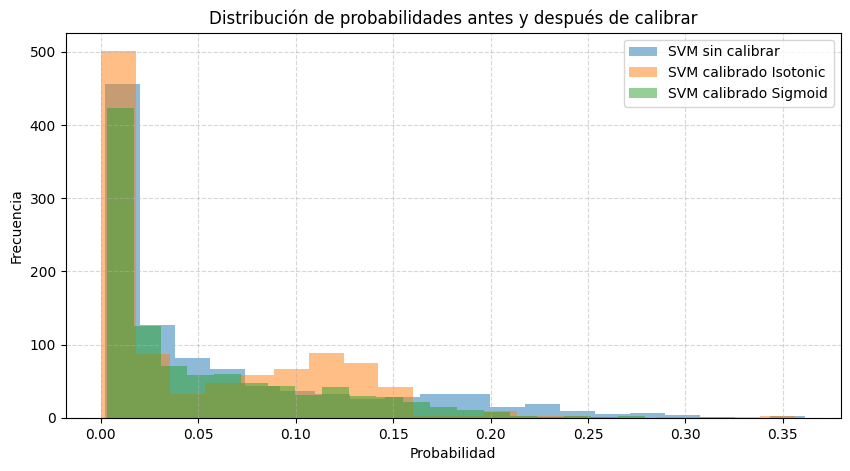

In [46]:
plt.figure(figsize=(10, 5))

# modelo sin calibrar
plt.hist(y_pred_proba, bins=20, alpha=0.5, label="SVM sin calibrar")

# modelo calibrado con Isotonic
plt.hist(y_probs_iso, bins=20, alpha=0.5, label="SVM calibrado Isotonic")

plt.hist(y_probs_platt, bins=20, alpha=0.5, label="SVM calibrado Sigmoid")

plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades antes y después de calibrar")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Podemos ver que la frecuencia de probabilidades para detectar un infarto son pocas, es decir que la mayoria de las veces no se van a detectar, no porque el modelo sea malo, sino porque existe un desbalance y en la realidad los casos son pocos.

Ahora graficamos la calibracion de los 3 modelos.

In [ ]:
def plot_calibration(y_true, probs_dict, title="Curva de calibración", size=(9,6)):
    plt.figure(figsize=size)
    plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")

    colors = plt.cm.Dark2.colors 
    
    for i, (name, prob) in enumerate(probs_dict.items()):
        color = colors[i % len(colors)]
        
        frac_pos, mean_pred = calibration_curve(
            y_true, prob, n_bins=10, strategy='uniform'
        )
        brier = brier_score_loss(y_true, prob)
        acc = accuracy_score(y_true, (prob >= 0.5).astype(int))

        plt.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2,
                 label=f"{name}\nBrier={brier:.3f} | Acc={acc:.3f}")

    plt.xlabel("Probabilidad predicha media")
    plt.ylabel("Fracción de positivos reales")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

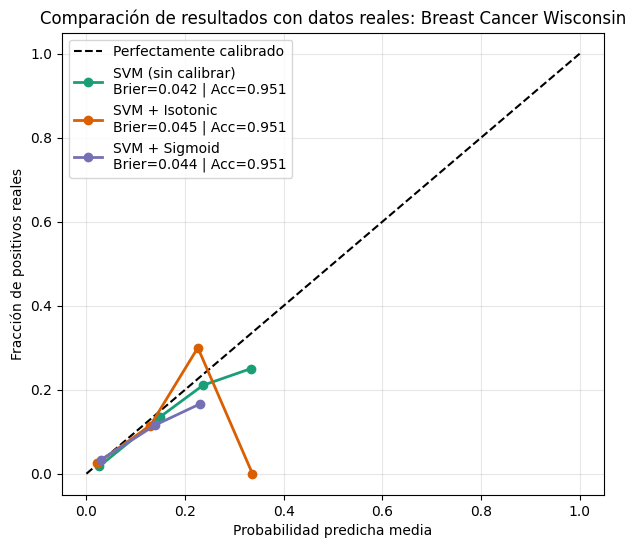

In [54]:
probs = {
    "SVM (sin calibrar)": y_pred_proba,
    "SVM + Isotonic": y_probs_iso,
    "SVM + Sigmoid": y_probs_platt
}

plot_calibration(y_test, probs, "Comparación de resultados con datos reales: Breast Cancer Wisconsin", size=(7,6))

Segun la grafica, las calibracion es buena siempre para 2 modelos para la no deteccion de infartos, mientras que para SVM - Isotonic no es muy bueno. Ademas podemos ver que se cuenta con poca informacion para detectar infartos fuertemente.

Veamos algunas metricas aplicando Brier, LogLoss, Acurrancy y Recall

In [52]:
def resumen_calibracion(y, probs, pred):
    return {
        "Brier": brier_score_loss(y, probs),
        "LogLoss": log_loss(y, probs),
        "Accuracy": accuracy_score(y, pred),
        "Recall": recall_score(y, pred),
    }

y_pred_platt = svm_platt.predict(X_test)
y_pred_iso = svm_iso.predict(X_test)
y_pred = svm.predict(X_test)

modelos = {
    "SVM (sin calibrar)": [y_pred_proba, y_pred],
    "SVM + Isotonic": [y_pred_iso, y_pred_iso],
    "SVM + Sigmoid": [y_pred_platt, y_pred_platt]
}

print(pd.DataFrame({k: resumen_calibracion(y_test, v[0], v[1]) for k,v in modelos.items()}).T)

                       Brier   LogLoss  Accuracy  Recall
SVM (sin calibrar)  0.042430  0.159017  0.722114    0.82
SVM + Isotonic      0.048924  1.763388  0.951076    0.00
SVM + Sigmoid       0.048924  1.763388  0.951076    0.00


c:\Users\cristian.aballay\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


Brien nos dice que tan bien calibrado se encuentra el modelo. Para los 3 modelos, la calibracion es similar, pero viendo el recall, podriamos considerar que el modelo original mantiene una mejor consistencia en las predicciones y nos da mas confianza.

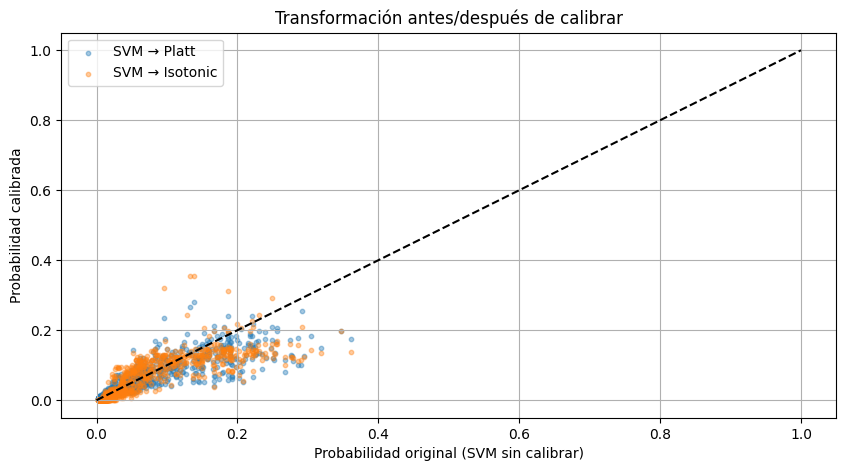

In [56]:
plt.figure(figsize=(10, 5))

plt.scatter(y_pred_proba, y_probs_platt, s=10, alpha=0.4, label="SVM → Platt")
plt.scatter(y_pred_proba, y_probs_iso, s=10, alpha=0.4, label="SVM → Isotonic")

plt.plot([0,1],[0,1],'k--') 
plt.xlabel("Probabilidad original (SVM sin calibrar)")
plt.ylabel("Probabilidad calibrada")
plt.title("Transformación antes/después de calibrar")
plt.legend()
plt.grid(True)
plt.show()
